In [1]:
!pip install sentence-transformers
from google.colab import files
uploaded_files = files.upload() # upload the local files from the computer

Saving data_preprocessed_csv.csv to data_preprocessed_csv.csv


In [49]:
#import libraries
import pandas as pd
import numpy as np
import sys
from sentence_transformers import SentenceTransformer   # the SBERT model
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

In [3]:
sys.path.insert(0,'/content') # looking in /content for any local files we uploaded

In [4]:
df = pd.read_csv('/content/data_preprocessed_csv.csv')

df['cleaned_abstract'] = df['cleaned_abstract'].fillna('') # handling missing values
df['abstract'] = df['abstract'].fillna('')

print("Dataset dimensions :",df.shape)
print("Columns in dataset :",df.columns.values)
print("\nFirst 2 rows of the abstract column :")
print(df['abstract'].head())

Dataset dimensions : (27121, 14)
Columns in dataset : ['id' 'submitter' 'authors' 'title' 'comments' 'journal-ref' 'doi'
 'abstract' 'report-no' 'categories' 'versions' 'year' 'cleaned_abstract'
 'period']

First 2 rows of the abstract column :
0      This paper uncovers and explores the close r...
1      In these notes we formally describe the func...
2      Motivation: Profile hidden Markov Models (pH...
3      We introduce a framework for filtering featu...
4      This paper proposes an approach to training ...
Name: abstract, dtype: object


# Using MiniLM Model

In [5]:
model_used = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
# Extracts abstracts and encode them into numerical embeddings using the model
abstracts = df['abstract'].tolist()
embeddings = model_used.encode(abstracts,batch_size=64,convert_to_numpy=True,show_progress_bar=True)
print(f"Embeddings shape : {embeddings.shape}")

Batches:   0%|          | 0/424 [00:00<?, ?it/s]

Embeddings shape : (27121, 384)


In [7]:
np.save('/content/embeddings_nithya.npy',embeddings) # save the embeddings to the computer
#files.download('/content/embeddings_nithya.npy')

In [8]:
def manual_cossim(ppr1,ppr2):
    return np.dot(ppr1,ppr2)/(np.linalg.norm(ppr1)*np.linalg.norm(ppr2))  # Implementing cosine similarity manually like lab

# Picking 2 random papers and checking their similarity score
ppr1 = embeddings[0]
ppr2 = embeddings[1]
similarity_score = manual_cossim(ppr1,ppr2)
print("\nPaper 1 is about :",df['abstract'].iloc[0])
print("\nPaper 2 is about :",df['abstract'].iloc[1])
print(f"Their similarity score is : {similarity_score : }") # Range betwen 0 to 1, higher means more similar


Paper 1 is about :   This paper uncovers and explores the close relationship between Monte Carlo
Optimization of a parametrized integral (MCO), Parametric machine-Learning
(PL), and `blackbox' or `oracle'-based optimization (BO). We make four
contributions. First, we prove that MCO is mathematically identical to a broad
class of PL problems. This identity potentially provides a new application
domain for all broadly applicable PL techniques: MCO. Second, we introduce
immediate sampling, a new version of the Probability Collectives (PC) algorithm
for blackbox optimization. Immediate sampling transforms the original BO
problem into an MCO problem. Accordingly, by combining these first two
contributions, we can apply all PL techniques to BO. In our third contribution
we validate this way of improving BO by demonstrating that cross-validation and
bagging improve immediate sampling. Finally, conventional MC and MCO procedures
ignore the relationship between the sample point locations and t

In [9]:
def table_of_similar_papers(query,top_k=10):
    query_embdng = model_used.encode([query],convert_to_numpy=True)[0]

    scores = []
    for e in embeddings:
        score = manual_cossim(query_embdng,e)
        scores.append(score)

    scores = np.array(scores)

    top_results = scores.argsort()[::-1][:top_k]

    results = df.iloc[top_results][['title','year','abstract']].copy()
    results['similarity score'] = scores[top_results].round(4)

    results['abstract'] = results['abstract'].str[:300]

    return results.reset_index(drop=True)

In [10]:
table_of_similar_papers("deep learning")

,title,year,abstract,similarity score
0,Introduction to deep learning,2020,Deep Learning (DL) has made a major impact o...,0.6653
1,Why & When Deep Learning Works: Looking Inside...,2017,The Intel Collaborative Research Institute f...,0.6076
2,Node-By-Node Greedy Deep Learning for Interpre...,2016,Multilayer networks have seen a resurgence u...,0.5963
3,Deep Learning of Representations: Looking Forward,2013,Deep learning research aims at discovering l...,0.5914
4,Layer-wise training of deep networks using ker...,2017,Deep learning has shown promising results in...,0.5810
5,Deep Neural Networks and Tabular Data: A Survey,2021,Heterogeneous tabular data are the most comm...,0.5793
6,Complementary Ensemble Learning,2021,To achieve high performance of a machine lea...,0.5778
7,Why and When Can Deep -- but Not Shallow -- Ne...,2016,The paper characterizes classes of functions...,0.5685
8,Practical recommendations for gradient-based t...,2012,Learning algorithms related to artificial ne...,0.5675
9,Data Distillation for Text Classification,2021,Deep learning techniques have achieved great...,0.5654


In [11]:
table_of_similar_papers("Natural language processing")

,title,year,abstract,similarity score
0,Natural Language Processing - A Survey,2012,The utility and power of Natural Language Pr...,0.6773
1,"Natural Language Processing: State of The Art,...",2017,Natural language processing (NLP) has recent...,0.6340
2,New Approaches for Natural Language Understand...,2020,We must recognize that natural language is a...,0.6278
3,Probabilistic Frame Induction,2013,"In natural-language discourse, related event...",0.6150
4,Towards Linguistically Generalizable NLP Syste...,2017,This paper presents a summary of the first W...,0.6122
5,Arithmetic Word Problem Solver using Frame Ide...,2018,Automatic Word problem solving has always po...,0.6003
6,Natural Language Understanding Based on Semant...,2012,"In this paper, we define event expression ov...",0.5993
7,Les Entit\'es Nomm\'ees : usage et degr\'es de...,2010,The recognition and classification of Named ...,0.5937
8,Towards a Heuristic Categorization of Preposit...,2010,This document discusses an approach and its ...,0.5934
9,An Empirical Comparison of Parsing Methods for...,2014,Stanford typed dependencies are a widely des...,0.5924


In [12]:
number_of_clusters = 10
kmeans_clustering = KMeans(n_clusters=number_of_clusters,random_state=33)
df['kmeans_clusters'] = kmeans_clustering.fit_predict(embeddings)
print("Number of papers in each cluster : \n")
print(df['kmeans_clusters'].value_counts().sort_index())

Number of papers in each cluster : 

kmeans_clusters
0    1902
1    2872
2    3100
3    2406
4    1643
5    2635
6    3225
7    2424
8    3310
9    3604
Name: count, dtype: int64


In [13]:
print("Few paper titles from each cluster :\n")
for c in range(number_of_clusters):
    paper_titles = df[df['kmeans_clusters'] == c]['title'].head(10)
    print(f"Few Papers in the Cluster {c} :")
    print(paper_titles.to_string(index=False))
    print()

Few paper titles from each cluster :

Few Papers in the Cluster 0 :
Constructing Folksonomies from User-specified R...
   Modeling Social Annotation: a Bayesian Approach
Identification of parameters underlying emotion...
Alleviating Media Bias Through Intelligent Agen...
        Tagging multimedia stimuli with ontologies
                  Semantic Social Network Analysis
Scalable Inference for Latent Dirichlet Allocation
Hierarchical Web Page Classification Based on a...
Exploring Language-Independent Emotional Acoust...
                                Emoticonsciousness

Few Papers in the Cluster 1 :
Induction of Word and Phrase Alignments for Aut...
    A Noisy-Channel Model for Document Compression
                 Recognizing Uncertainty in Speech
Xapagy: a cognitive architecture for narrative ...
An Application of Reinforcement Learning to Dia...
Automatically Training a Problematic Dialogue P...
Inferring Strategies for Sentence Ordering in M...
   Grounded Semantic Composition f

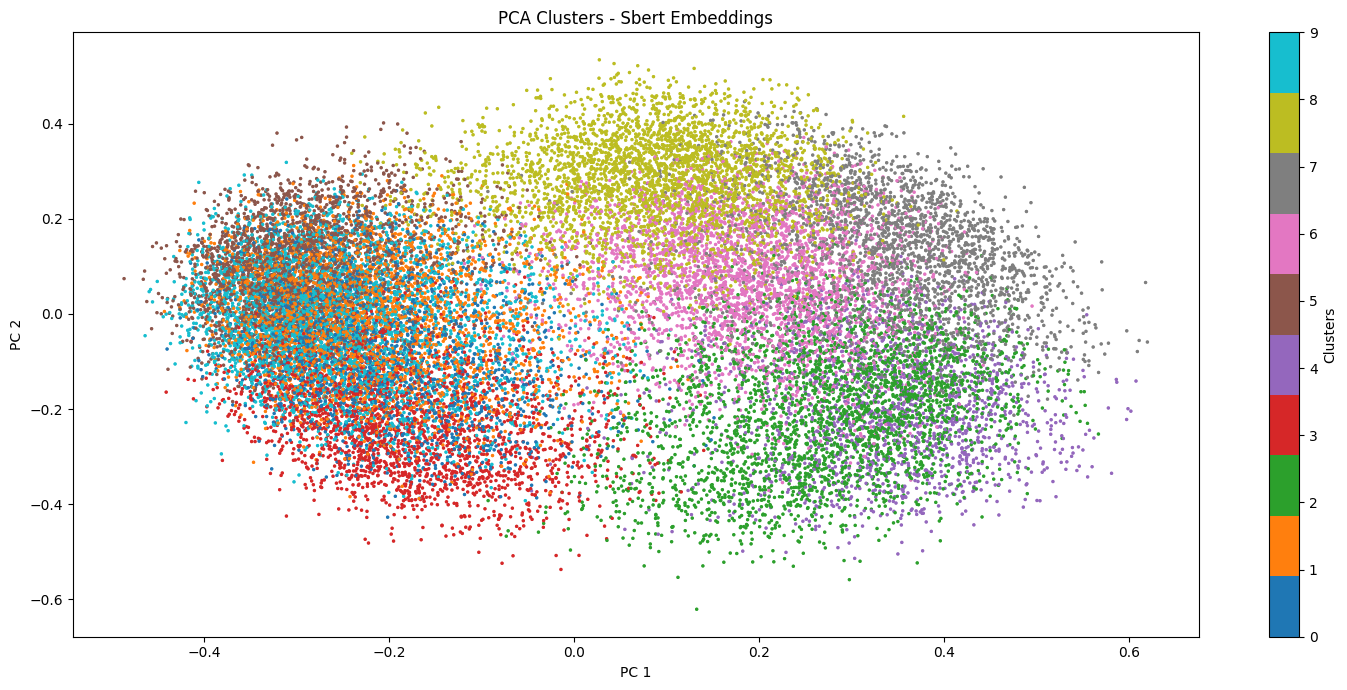

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
X_matrix = embeddings
mu = X_matrix.mean(axis=0)
Z = X_matrix - mu

cov_matrix = np.cov(Z,rowvar=False)

eigvals, eigvecs = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:,idx]
pca_projection = Z @ eigvecs[:,:2]

df['pca_1'] = pca_projection[:,0]
df['pca_2'] = pca_projection[:,1]

fig, ax = plt.subplots(figsize=(15,7))

scatter = ax.scatter(df['pca_1'],df['pca_2'],c=df['kmeans_clusters'],cmap='tab10',s=2)

plt.colorbar(scatter,ax=ax,label='Clusters')

ax.set_title('PCA Clusters - Sbert Embeddings',fontsize=12)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.tight_layout()

plt.savefig('/content/pca_clusters_nithya_sbert.png',dpi=150)
plt.show()

files.download('/content/pca_clusters_nithya_sbert.png')

In [15]:
print(df.head())

         id           submitter  \
0  704.1274      Dev Rajnarayan   
1  704.1394  Tarik Had\v{z}i\'c   
2  704.2010   Juliana Bernardes   
3  704.2668        Alex Smola J   
4  704.3433   Tshilidzi Marwala   

                                             authors  \
0             David H. Wolpert and Dev G. Rajnarayan   
1  Tarik Hadzic, Rune Moller Jensen, Henrik Reif ...   
2  Juliana S Bernardes, Alberto Davila, Vitor San...   
3  Le Song, Alex Smola, Arthur Gretton, Karsten B...   
4            Tshilidzi Marwala and Bodie Crossingham   

                                               title             comments  \
0   Parametric Learning and Monte Carlo Optimization                  NaN   
1  Calculating Valid Domains for BDD-Based Intera...                  NaN   
2  A study of structural properties on profiles HMMs   6 pages, 7 figures   
3  Supervised Feature Selection via Dependence Es...              9 pages   
4                     Bayesian approach to rough set  20 pages, 3 f

In [16]:
print(df['period'].value_counts().sort_index())

period
2005-2009      413
2010-2014     3762
2015-2019    10773
2020-2025    12173
Name: count, dtype: int64


In [17]:
print("Oldest Year :",df['year'].min())
print("Latest Year :",df['year'].max())
print("Total num of papers :",len(df))

Oldest Year : 2007
Latest Year : 2021
Total num of papers : 27121


# Experimenting with another model - Specter

In [18]:
model_specter = SentenceTransformer('sentence-transformers/allenai-specter')  #using specter model to compare with MiniLM

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/331 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
similarity_score_comparision = model_specter.encode([df['abstract'].iloc[0], df['abstract'].iloc[1]],convert_to_numpy=True)
specter_similarity_score = manual_cossim(similarity_score_comparision[0],similarity_score_comparision[1])
print(f"MiniLM similarity score : {similarity_score :}")
print(f"Specter similarity score : {specter_similarity_score :}")

MiniLM similarity score : 0.25005942583084106
Specter similarity score : 0.7725767493247986


In [20]:
specter_model_embeddings = model_specter.encode(df['abstract'].tolist(),batch_size=64,convert_to_numpy=True,show_progress_bar=True)
print(specter_model_embeddings.shape)

Batches:   0%|          | 0/424 [00:00<?, ?it/s]

(27121, 768)


In [21]:
np.save('/content/specter_model_embeddings_nithya.npy',specter_model_embeddings)
#files.download('/content/specter_model_embeddings_nithya.npy')

In [22]:
k_means_test = KMeans(n_clusters=10,random_state=33)

minilm_label = k_means_test.fit_predict(embeddings)
minilm_similarity_score = silhouette_score(embeddings,minilm_label,metric='cosine',sample_size=3000)

specter_label = k_means_test.fit_predict(specter_model_embeddings)
specter_similarity_score = silhouette_score(specter_model_embeddings,specter_label,metric='cosine',sample_size=3000)

print(f"MiniLM silhouette score : {minilm_similarity_score:}")
print(f"Specter silhouette score : {specter_similarity_score:}")

MiniLM silhouette score : 0.057704854756593704
Specter silhouette score : 0.09069637209177017


In [23]:
# trying different k values

k_vals = []
for v in range(5,20):
    k_vals.append(v)

minilm_similarity_score_k = []
specter_similarity_score_k = []

for k in k_vals:
    k_means = KMeans(n_clusters=k,random_state=33)

    minilm_labels_k = k_means.fit_predict(embeddings)
    minilm_similarity_score_k.append(silhouette_score(embeddings,minilm_labels_k,metric='cosine',sample_size=3000))

    specter_labels_k = k_means.fit_predict(specter_model_embeddings)
    specter_similarity_score_k.append(silhouette_score(specter_model_embeddings,specter_labels_k,metric='cosine',sample_size=3000))

    print(f"k = {k}  MiniLM = {minilm_similarity_score_k[-1]:.4f}  Specter = {specter_similarity_score_k[-1]:.4f}")

k = 5  MiniLM = 0.0618  Specter = 0.0914
k = 6  MiniLM = 0.0549  Specter = 0.0963
k = 7  MiniLM = 0.0509  Specter = 0.0878
k = 8  MiniLM = 0.0563  Specter = 0.0998
k = 9  MiniLM = 0.0574  Specter = 0.0954
k = 10  MiniLM = 0.0588  Specter = 0.0968
k = 11  MiniLM = 0.0571  Specter = 0.0897
k = 12  MiniLM = 0.0560  Specter = 0.0937
k = 13  MiniLM = 0.0665  Specter = 0.0936
k = 14  MiniLM = 0.0649  Specter = 0.0934
k = 15  MiniLM = 0.0572  Specter = 0.0912
k = 16  MiniLM = 0.0603  Specter = 0.1026
k = 17  MiniLM = 0.0667  Specter = 0.1006
k = 18  MiniLM = 0.0655  Specter = 0.0935
k = 19  MiniLM = 0.0642  Specter = 0.0948


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

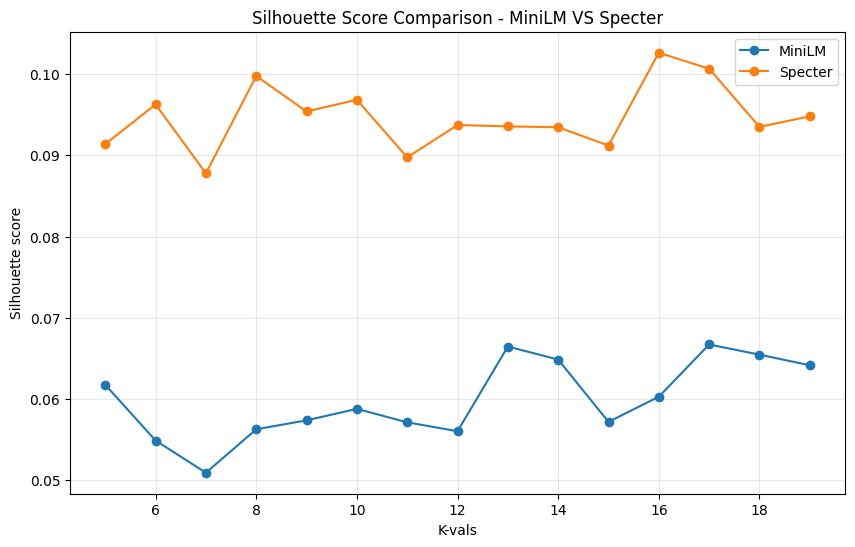

In [24]:
# plotting the silhouette scores

plt.figure(figsize=(10,6))
plt.plot(k_vals,minilm_similarity_score_k,marker='o',label='MiniLM')
plt.plot(k_vals,specter_similarity_score_k,marker='o',label='Specter')
plt.xlabel('K-vals')
plt.ylabel('Silhouette score')  # higher the better
plt.title('Silhouette Score Comparison - MiniLM VS Specter')
plt.legend()
plt.grid(True,alpha=0.3)
plt.savefig('/content/silhouette_comparison_minilm_vs_specter.png',dpi=150)
files.download('/content/silhouette_comparison_minilm_vs_specter.png')
plt.show()

# Using one more model MPNet for comparision


In [25]:
model_mpnet = SentenceTransformer('all-mpnet-base-v2')  # experimenting with another model MPNet

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [26]:
mpnet_model_embeddings = model_mpnet.encode(df['abstract'].tolist(),show_progress_bar=True)
print(mpnet_model_embeddings.shape)
np.save('/content/mpnet_model_embeddings_nithya.npy',mpnet_model_embeddings)
#files.download('/content/mpnet_model_embeddings_nithya.npy')

Batches:   0%|          | 0/848 [00:00<?, ?it/s]

(27121, 768)


In [27]:
embeddings_dict = {'MiniLM':embeddings,'MPNet':mpnet_model_embeddings,'Specter':specter_model_embeddings} # storing all 3 model's embeddings as a dict for easier access
for model_name,embdngs in embeddings_dict.items():
    print(model_name,embdngs.shape) # to verify if all 3 gives same num of rows like it should

MiniLM (27121, 384)
MPNet (27121, 768)
Specter (27121, 768)


In [28]:
print("Silhouette Scores for all 3 models :")  # comparing all 3 models
for model_name,embdngs in embeddings_dict.items():
    k_means = KMeans(n_clusters=10,random_state=33)
    labels = k_means.fit_predict(embdngs)
    silh_score = silhouette_score(embdngs,labels,metric='cosine',sample_size=3000)
    print(f"{model_name} : {silh_score:.4f}")

Silhouette Scores for all 3 models :
MiniLM : 0.0557
MPNet : 0.0698
Specter : 0.0917


# Can the models tell the time periods apart?

In [29]:
period_nums = LabelEncoder().fit_transform(df['period'])
for model_name,embdngs in embeddings_dict.items():
    silh_score = silhouette_score(embdngs,period_nums,metric='cosine',sample_size=9000)
    print(f"{model_name} : {silh_score:.4f}")

MiniLM : -0.0002
MPNet : -0.0018
Specter : -0.0180


# PCA

In [30]:
X_spec = specter_model_embeddings
mu_spec = X_spec.mean(axis=0)
Z_spec = X_spec - mu_spec

R_spec = np.cov(Z_spec,rowvar=False)
evals_spec, evecs_spec = np.linalg.eigh(R_spec)

idx_spec = np.argsort(evals_spec)[::-1]
evecs_spec = evecs_spec[:,idx_spec]

pca_coords = Z_spec @ evecs_spec[:,:2]

df['pca_x'] = pca_coords[:,0]
df['pca_y'] = pca_coords[:,1]

total_var = np.sum(evals_spec)
print(f"PC 1 : {(evals_spec[idx_spec[0]]/total_var)*100:.2f}%")
print(f"PC 2 : {(evals_spec[idx_spec[1]]/total_var)*100:.2f}%")

PC 1 : 12.22%
PC 2 : 6.10%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

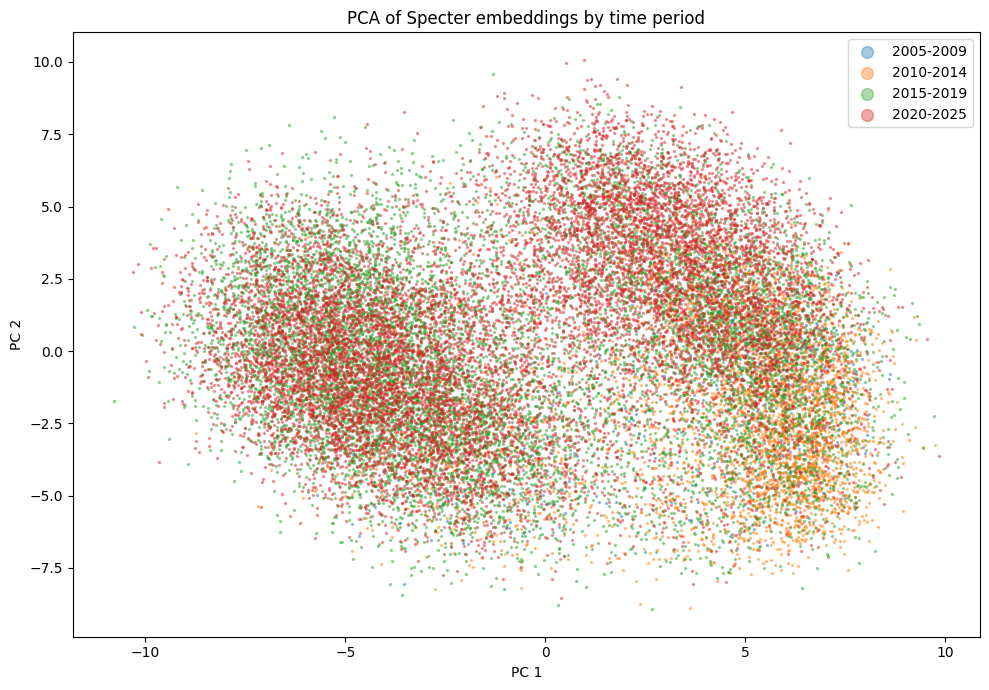

In [31]:
fig,ax = plt.subplots(figsize=(10,7))

period_order = ['2005-2009','2010-2014','2015-2019','2020-2025']

for p in period_order:
    mask = df['period'] == p
    ax.scatter(df.loc[mask,'pca_x'],df.loc[mask,'pca_y'],label=p,s=2,alpha=0.4)

ax.set_title('PCA of Specter embeddings by time period')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(markerscale=6)
plt.tight_layout()
plt.savefig('/content/pca_by_period_nithya.png',dpi=150)
files.download('/content/pca_by_period_nithya.png')
plt.show()

# Visualising the Trajectory of the field

In [32]:
centroid_x_coord = []
centroid_y_coord = []

for p in period_order:
    mask = df['period'] == p

    mean_x = df.loc[mask,'pca_x'].mean()
    mean_y = df.loc[mask,'pca_y'].mean()

    centroid_x_coord.append(mean_x)
    centroid_y_coord.append(mean_y)
    print(f"Centroid for {p} : ({mean_x:.4f},{mean_y:.4f})")

Centroid for 2005-2009 : (3.5323,-2.0041)
Centroid for 2010-2014 : (4.3118,-2.0386)
Centroid for 2015-2019 : (-0.8703,-0.1025)
Centroid for 2020-2025 : (-0.6822,0.7887)


/tmp/ipykernel_1140/397419442.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


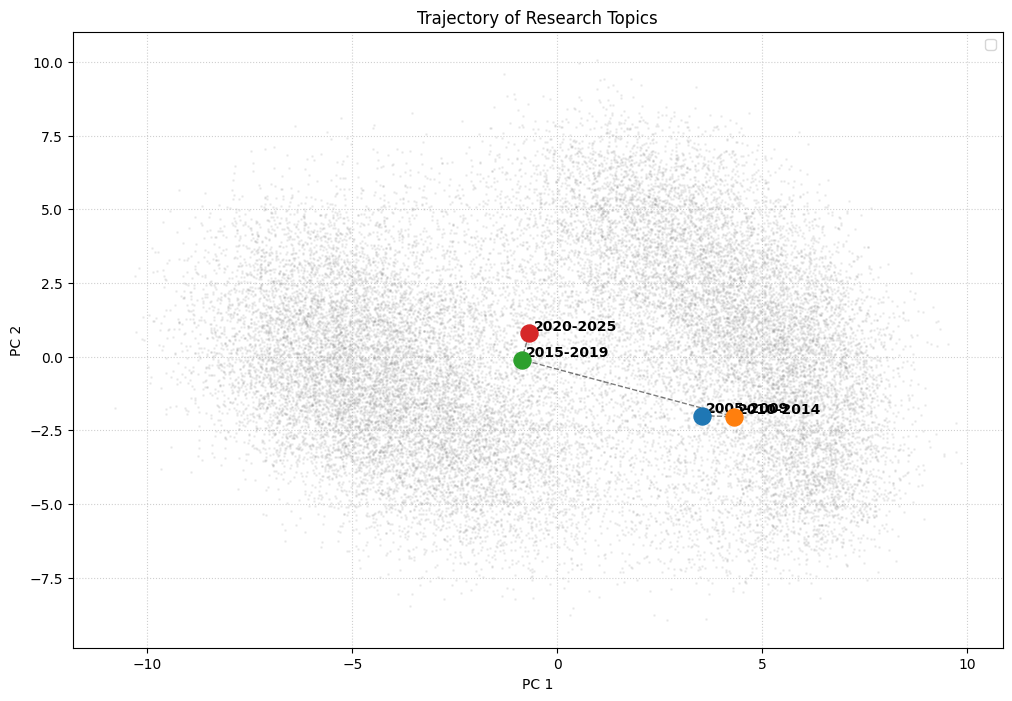

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(12,8))

plt.scatter(df['pca_x'],df['pca_y'],s=1,alpha=0.1,color='gray')

plt.plot(centroid_x_coord,centroid_y_coord,'k--',alpha=0.5,linewidth=1) # dashed line connecting centroids to show change

for i, p in enumerate(period_order):
    plt.scatter(centroid_x_coord[i],centroid_y_coord[i],s=150,zorder=5)
    plt.text(centroid_x_coord[i]+0.1,centroid_y_coord[i]+0.1,p,fontsize=10,fontweight='bold',color='black')

plt.title('Trajectory of Research Topics')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True,linestyle=':',alpha=0.6) # Standard worksheet grid style
plt.show()
plt.savefig('/content/trajectory_topics_nithya.png',dpi=150)
files.download('/content/trajectory_topics_nithya.png')

# By how much the field changed between each period


In [34]:
space_row = []

for model_name,embdngs in embeddings_dict.items():
    centroids = {}
    for p in period_order:
        mask = df['period'] == p
        centroids[p] = embdngs[mask].mean(axis=0)
    for i in range(len(period_order)-1):
        p1 = period_order[i]
        p2 = period_order[i+1]
        cos_sim = manual_cossim(centroids[p1],centroids[p2])
        space_row.append({'model':model_name,'period from':p1,'period to':p2,'distance':round(1-cos_sim,4)})

space_table = pd.DataFrame(space_row)
print(space_table)

     model period from  period to  distance
0   MiniLM   2005-2009  2010-2014    0.0589
1   MiniLM   2010-2014  2015-2019    0.2426
2   MiniLM   2015-2019  2020-2025    0.0165
3    MPNet   2005-2009  2010-2014    0.0566
4    MPNet   2010-2014  2015-2019    0.2577
5    MPNet   2015-2019  2020-2025    0.0154
6  Specter   2005-2009  2010-2014    0.0071
7  Specter   2010-2014  2015-2019    0.0489
8  Specter   2015-2019  2020-2025    0.0044


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

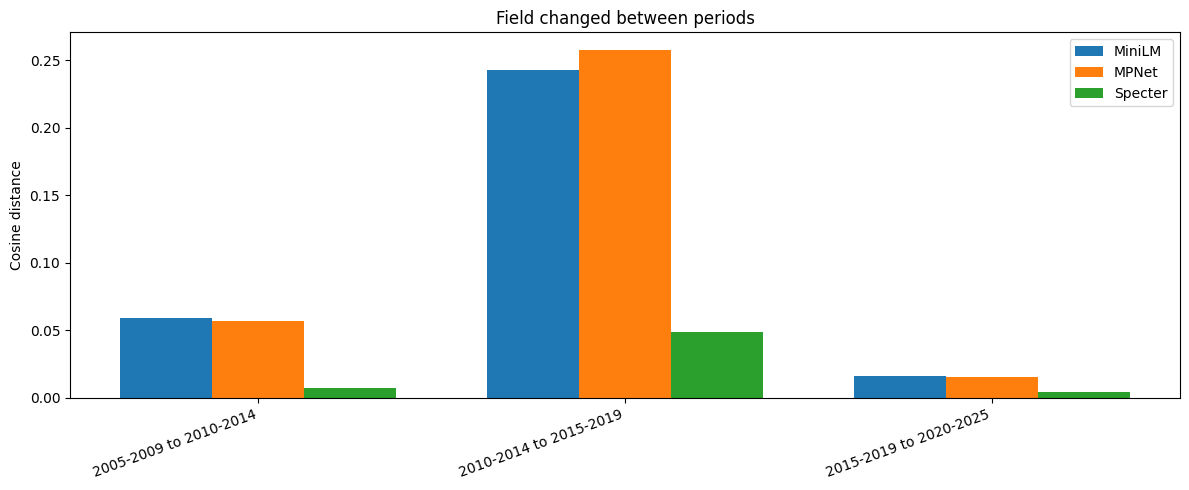

In [35]:
transitions = [f"{period_order[i]} to {period_order[i+1]}" for i in range(len(period_order) - 1)]

fig, ax = plt.subplots(figsize=(12,5))
bar_width = 0.25
x = np.arange(len(transitions))

for i,model_name in enumerate(['MiniLM','MPNet','Specter']):
    rows = space_table[space_table['model'] == model_name]
    ax.bar(x+i*bar_width,rows['distance'].tolist(),bar_width,label=model_name)

ax.set_xticks(x+bar_width)
ax.set_xticklabels(transitions,rotation=20,ha='right')
ax.set_ylabel('Cosine distance')
ax.set_title('Field changed between periods')
ax.legend()
plt.tight_layout()
plt.savefig('/content/field_changed_between_periods_nithya.png',dpi=150)
files.download('/content/field_changed_between_periods_nithya.png')
plt.show()

# Analysing how communication and meaning has changed

In [36]:
def find_pprs_for_term(description,period,top_k=8):
    term_emb = model_specter.encode([description],convert_to_numpy=True)[0]
    mask = df['period'] == period
    period_df = df[mask].reset_index(drop=True)
    period_embdngs = specter_model_embeddings[mask]

    scores = []
    for pe in period_embdngs:
        cos_sim = manual_cossim(term_emb,pe)
        scores.append(cos_sim)

    scores = np.array(scores)
    top_idx = scores.argsort()[-top_k:][::-1]

    results = period_df.iloc[top_idx][['year','title']].copy()
    results['similarity_score'] = scores[top_idx].round(3)
    return results.reset_index(drop=True)

In [37]:
print("'language models' across periods:\n")

for p in period_order:
    print(f"{[p]} :")
    r = find_pprs_for_term('a model that predicts and generates natural language text',p)
    print(r[['year','title']].to_string(index=False))
    print()

'language models' across periods:

['2005-2009'] :
 year                                                                                                    title
 2007                                                                                In memoriam Maurice Gross
 2009                          Induction of Word and Phrase Alignments for Automatic Document\n  Summarization
 2008       Methods to integrate a language model with semantic information for a\n  word prediction component
 2007                                              Bootstrapping Deep Lexical Resources: Resources for Courses
 2008                 Computational Representation of Linguistic Structures using\n  Domain-Specific Languages
 2008                             Determining the Unithood of Word Sequences using a Probabilistic\n  Approach
 2007                   A Robust Linguistic Platform for Efficient and Domain specific Web\n  Content Analysis
 2008 Utilisation des grammaires probabilistes dans les t\^ac

In [38]:
# trying another one

print("'neural network' across periods:\n")

for p in period_order:
    print(f"{[p]} :")
    r = find_pprs_for_term('deep neural network architecture',p)
    print(r[['year','title']].to_string(index=False))
    print()

'neural network' across periods:

['2005-2009'] :
 year                                                                                                     title
 2008                            Prediction of Platinum Prices Using Dynamically Weighted Mixture of\n  Experts
 2007                                                                             Tests of Machine Intelligence
 2007            Comparing Robustness of Pairwise and Multiclass Neural-Network Systems\n  for Face Recognition
 2008                                                                From Data Topology to a Modular Classifier
 2008                                                    Introduction to Relational Networks for Classification
 2007 Response Prediction of Structural System Subject to Earthquake Motions\n  using Artificial Neural Network
 2009                                     An optimal linear separator for the Sonar Signals Classification task
 2007                                               Bo

# Analysing how focus has changed


In [39]:
# measuring average distance within each period
diversity_rows_period = []

for model_name,embdngs in embeddings_dict.items():
    for p in period_order:
        mask = df['period'] == p
        period_embdngs = embdngs[mask]
        centroid = period_embdngs.mean(axis=0)
        if len(period_embdngs)>1000:
            choice = np.random.choice(len(period_embdngs),1000,replace=False)
            sample_embdngs = period_embdngs[choice]
        else:
            sample_embdngs = period_embdngs
        dist = []
        for se in sample_embdngs:
            cos_sim = manual_cossim(se,centroid)
            dist.append(1 - cos_sim)
        avg_diversity = np.mean(dist)
        diversity_rows_period.append({'model': model_name,'period': p,'diversity_score': round(avg_diversity,4)})

diversity_table = pd.DataFrame(diversity_rows_period)
print(diversity_table)

      model     period  diversity_score
0    MiniLM  2005-2009           0.6078
1    MiniLM  2010-2014           0.5612
2    MiniLM  2015-2019           0.5092
3    MiniLM  2020-2025           0.4944
4     MPNet  2005-2009           0.5757
5     MPNet  2010-2014           0.5343
6     MPNet  2015-2019           0.4977
7     MPNet  2020-2025           0.4864
8   Specter  2005-2009           0.1809
9   Specter  2010-2014           0.1657
10  Specter  2015-2019           0.1878
11  Specter  2020-2025           0.1947


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

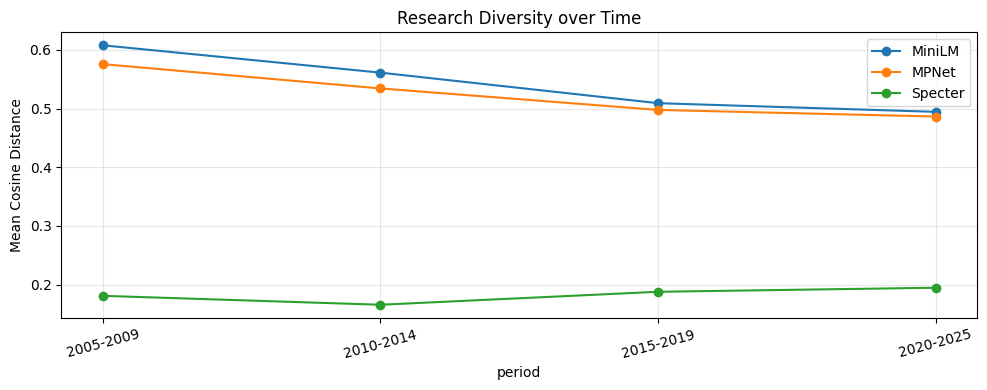

In [40]:
fig,ax = plt.subplots(figsize=(10,4))

for model_name in ['MiniLM','MPNet','Specter']:
    rows = diversity_table[diversity_table['model'] == model_name]
    rows = rows.set_index('period').reindex(period_order)
    ax.plot(period_order,rows['diversity_score'].values,marker='o',label=model_name)

ax.set_xlabel('period')
ax.set_ylabel('Mean Cosine Distance')
ax.set_title('Research Diversity over Time')
ax.legend()
ax.grid(True,alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/content/diversity_over_time_nithya.png',dpi=150)
files.download('/content/diversity_over_time_nithya.png')
plt.show()

# Analysing how framing has changed

In [41]:
eg_sentence = {'state-of-the-art': 'Our approach achieves state-of-the-art results on standard benchmarks',
             'theoretical': 'We provide a formal analysis of properties and establish theoretical results',
             'real-world appln': 'We demonstrate the practical application of our framework in a real-world scenario',
             'new dataset': 'We present a novel, large-scale annotated dataset',
             'scaling up': 'We scale our model to billions of parameters',
             'interpretability': 'We analyse what the model has learned internally'}

names = list(eg_sentence.keys())
framing_embdngs = model_specter.encode(list(eg_sentence.values()),convert_to_numpy=True)
print(framing_embdngs.shape)

(6, 768)


In [50]:
results = {}

for p in period_order:
    mask = df['period'] == p
    period_embdngs = specter_model_embeddings[mask]
    if len(period_embdngs)>800:
        choice = np.random.choice(len(period_embdngs),800,replace=False)
        p_embdngs = period_embdngs[choice]
    else:
        p_embdngs = period_embdngs
    period_scores = []
    for framing_emb in framing_embdngs:
        sims = []
        for p_emb in p_embdngs:
            sims.append(manual_cossim(framing_emb,p_emb))
        period_scores.append(np.mean(sims))
    similarity = np.dot(framing_embdngs,p_embdngs.T)
    results[p] = similarity.mean(axis=1)

result_table = pd.DataFrame(results,index=names)
print(result_table.round(4))

                   2005-2009   2010-2014   2015-2019   2020-2025
state-of-the-art  302.938202  303.228210  314.466888  312.415405
theoretical       327.090790  331.049896  304.007812  298.840302
real-world appln  320.823792  324.977203  315.364288  316.581696
new dataset       332.048615  332.895996  336.842590  334.692902
scaling up        322.458588  326.668396  314.241699  312.484894
interpretability  302.729492  308.393890  311.718414  312.107910


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

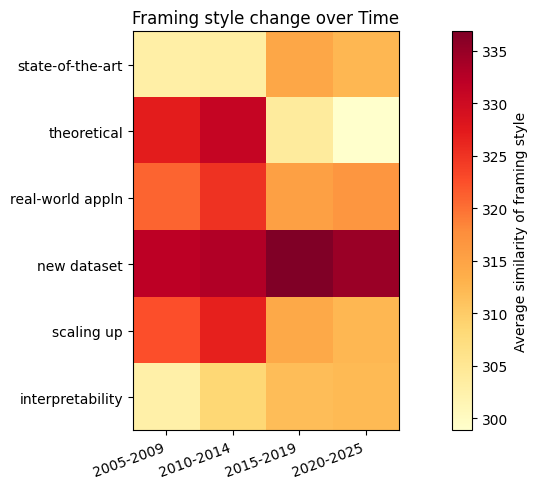

In [51]:
fig,ax = plt.subplots(figsize=(11,5))

image = ax.imshow(result_table.values,cmap='YlOrRd')

ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order,rotation=20,ha='right')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)

plt.colorbar(image,ax=ax,label='Average similarity of framing style')
ax.set_title('Framing style change over Time')
plt.tight_layout()
plt.savefig('/content/framing_style_heatmap_nithya.png',dpi=150)
files.download('/content/framing_style_heatmap_nithya.png')
plt.show()